# Model Evaluation

This notebook evaluates the performance of all trained machine learning models using different evaluation metrics and visualization techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
DATA_PATH = Path("../DATA/processed")

X_test = pd.read_csv(DATA_PATH / "X_test.csv")

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze()

print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_test Shape: (800, 47)
y_test Shape: (800,)


In [3]:
# Load Trained Models
MODEL_PATH = Path("../MODELS")

logistic_model = joblib.load(
    MODEL_PATH / "logistic_regression.pkl"
)

decision_tree = joblib.load(
    MODEL_PATH / "decision_tree.pkl"
)

random_forest = joblib.load(
    MODEL_PATH / "random_forest_model.pkl"
)

print("All Models Loaded Successfully")

All Models Loaded Successfully


In [4]:
# Generate Predictions
logistic_pred = logistic_model.predict(X_test)

decision_tree_pred = decision_tree.predict(X_test)

random_forest_pred = random_forest.predict(X_test)

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [5]:
# Model Performance Comparison
results = []

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

for name, pred in predictions.items():

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            pred,
            zero_division=0
        )

    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.98500,0.0,0.0,0.0
1,Decision Tree,0.99750,0.0,0.0,0.0
2,Random Forest,0.99875,0.0,0.0,0.0


In [6]:
# Best Performing Model
best_model = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

best_model


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.98500,0.0,0.0,0.0
1,Decision Tree,0.99750,0.0,0.0,0.0
2,Random Forest,0.99875,0.0,0.0,0.0


<Figure size 500x400 with 0 Axes>

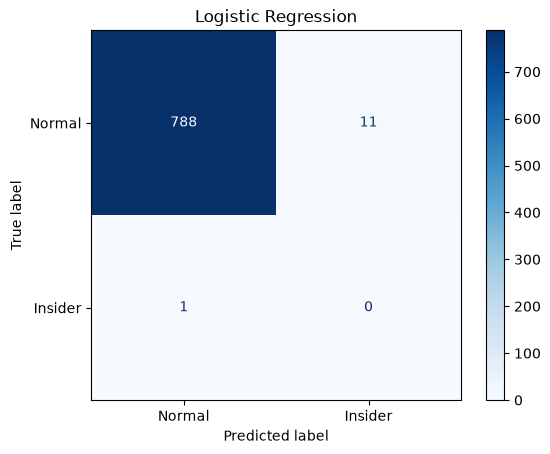

<Figure size 500x400 with 0 Axes>

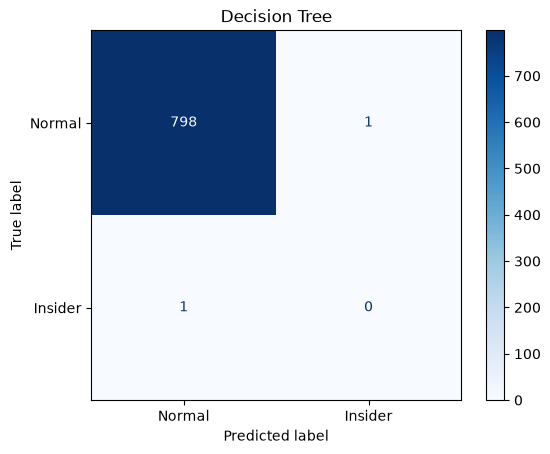

<Figure size 500x400 with 0 Axes>

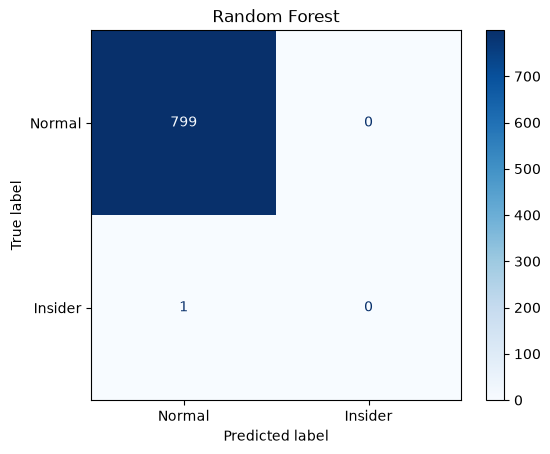

In [7]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

for name, pred in predictions.items():

    plt.figure(figsize=(5,4))

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Insider"]
    )

    disp.plot(cmap="Blues")

    plt.title(name)

    plt.show()

In [8]:
# Classification Report
for name, pred in predictions.items():

    print("="*60)

    print(name)

    print("="*60)

    print(
        classification_report(
            y_test,
            pred,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       799
           1       0.00      0.00      0.00         1

    accuracy                           0.98       800
   macro avg       0.50      0.49      0.50       800
weighted avg       1.00      0.98      0.99       800

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       799
           1       0.00      0.00      0.00         1

    accuracy                           1.00       800
   macro avg       0.50      0.50      0.50       800
weighted avg       1.00      1.00      1.00       800

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       799
           1       0.00      0.00      0.00         1

    accuracy                           1.00       800
   macro avg       0.50      0.50      0.50       800
weighted avg       1.00   

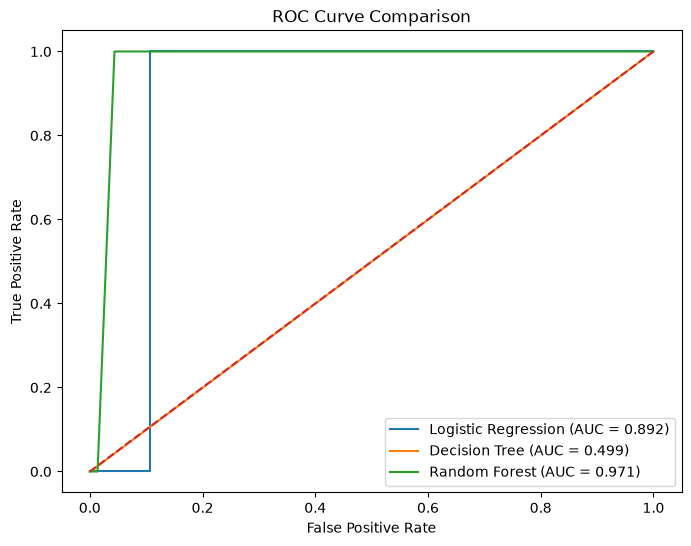

In [9]:
# ROC Curve
plt.figure(figsize=(8,6))

for name, model in models.items():

    probabilities = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [10]:
# ROC-AUC Scores
auc_results = []

for name, model in models.items():

    probabilities = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    auc_results.append({
        "Model": name,
        "ROC-AUC": auc
    })

auc_df = pd.DataFrame(auc_results)

auc_df

,Model,ROC-AUC
0,Logistic Regression,0.892365
1,Decision Tree,0.499374
2,Random Forest,0.971214


In [11]:
# Load original dataset to get feature names
df = pd.read_csv("../DATA/processed/labeled_dataset.csv")

# Remove non-feature columns
feature_names = df.drop(columns=["user", "label"]).columns

# Create Feature Importance DataFrame
importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": random_forest.feature_importances_

})

# Sort by Importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 20 Features
importance.head(20)

,Feature,Importance
6,working_days,0.143062
36,http_download_count,0.123784
37,http_upload_count,0.097655
14,after_hours_device_events,0.088827
28,files_to_removable_media,0.080292
26,file_write_count,0.068204
29,files_from_removable_media,0.061879
12,total_connects,0.053638
25,file_copy_count,0.048880
31,unique_pcs_y,0.031362


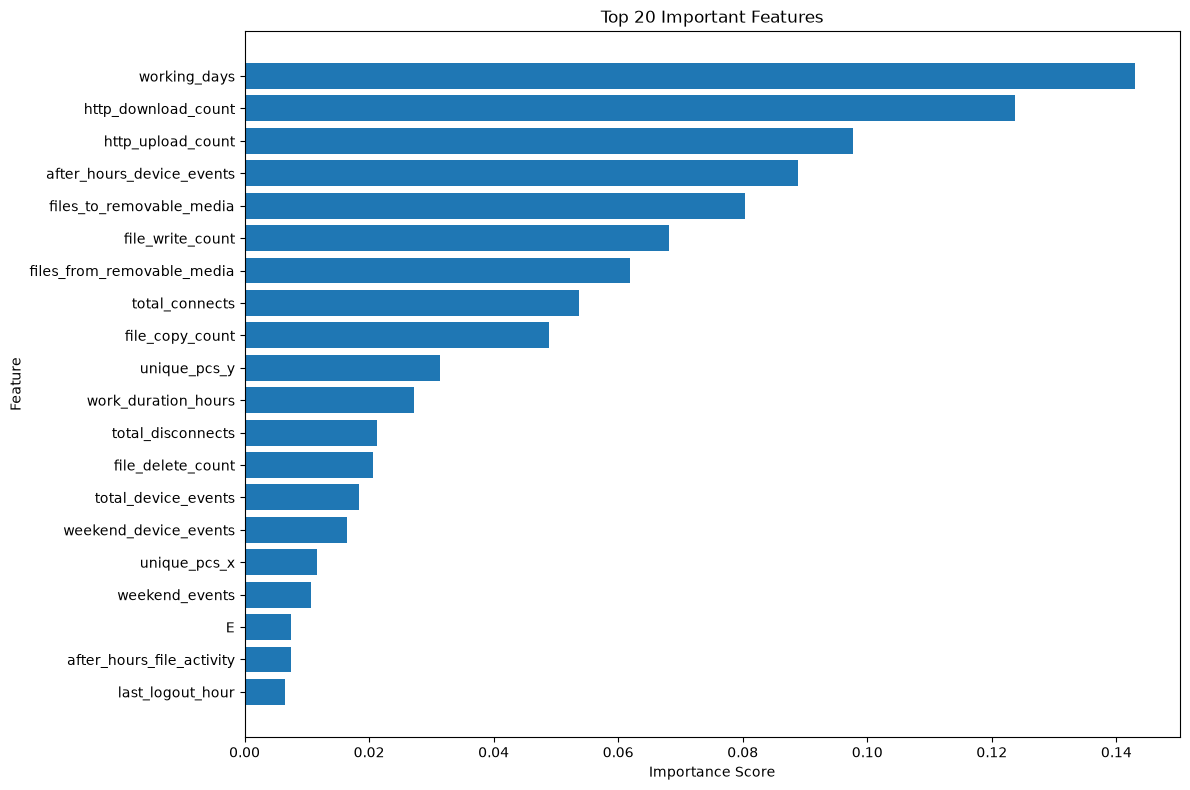

In [12]:
top20 = importance.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [13]:
# Save Feature Importance
importance.to_csv(
    "../DATA/processed/feature_importance.csv",
    index=False
)

print("Feature Importance Saved Successfully")

Feature Importance Saved Successfully


In [14]:
# Model Evaluation Summary
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results_df)

print("\n")

print("=" * 60)
print("ROC-AUC SCORES")
print("=" * 60)

print(auc_df)

print("\n")

print("=" * 60)
print("TOP 10 IMPORTANT FEATURES")
print("=" * 60)

print(importance.head(10))

MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression   0.98500        0.0     0.0       0.0
1        Decision Tree   0.99750        0.0     0.0       0.0
2        Random Forest   0.99875        0.0     0.0       0.0


ROC-AUC SCORES
                 Model   ROC-AUC
0  Logistic Regression  0.892365
1        Decision Tree  0.499374
2        Random Forest  0.971214


TOP 10 IMPORTANT FEATURES
                       Feature  Importance
6                 working_days    0.143062
36         http_download_count    0.123784
37           http_upload_count    0.097655
14   after_hours_device_events    0.088827
28    files_to_removable_media    0.080292
26            file_write_count    0.068204
29  files_from_removable_media    0.061879
12              total_connects    0.053638
25             file_copy_count    0.048880
31                unique_pcs_y    0.031362


# Part B - Stratified K-Fold Cross Validation

Since the CERT Insider Threat dataset is highly imbalanced, evaluating the model using only a single train-test split may not provide reliable performance estimates.

Stratified K-Fold Cross Validation maintains the same class distribution in every fold and provides a more robust evaluation of model performance.

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

In [16]:
DATA_PATH = Path("../DATA/processed")

df = pd.read_csv(
    DATA_PATH / "labeled_dataset.csv"
)

print(df.shape)

df.head()

(4000, 49)


,user,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,...,after_hours_http_count,weekend_http_count,unique_urls,unique_http_pcs,O,C,E,A,N,label
0,AAB0162,711,355,356,705.0,0.0,1,356,1.997191,7,...,4277,0,144,1,45,36,33,15,33,0
1,AAB0398,712,356,356,356.0,0.0,1,356,2.000000,6,...,7128,0,351,1,16,38,16,26,34,0
2,AAC0610,1052,665,387,222.0,5.0,1,360,2.922222,0,...,240,0,267,1,46,35,50,42,31,0
3,AAC0668,712,356,356,158.0,0.0,1,356,2.000000,7,...,320,0,227,1,38,48,37,38,37,0
4,AAC3270,712,356,356,0.0,0.0,1,356,2.000000,8,...,0,0,60,1,26,37,42,45,30,0


In [17]:
# Create Features and Labels
X = df.drop(
    columns=["user", "label"]
)

y = df["label"]

print(X.shape)

print(y.value_counts())

(4000, 47)
label
0    3995
1       5
Name: count, dtype: int64


In [18]:
# Create Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(skf)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [19]:
# Cross Validation Scores
scoring = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1"

}

cv_results = cross_validate(

    random_forest,

    X,

    y,

    cv=skf,

    scoring=scoring,

    n_jobs=-1

)

print("Cross Validation Completed")

Cross Validation Completed


In [20]:
# Mean Cross Validation Scores
cv_summary = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Mean Score": [

        cv_results["test_accuracy"].mean(),

        cv_results["test_precision"].mean(),

        cv_results["test_recall"].mean(),

        cv_results["test_f1"].mean()

    ],

    "Standard Deviation": [

        cv_results["test_accuracy"].std(),

        cv_results["test_precision"].std(),

        cv_results["test_recall"].std(),

        cv_results["test_f1"].std()

    ]

})

cv_summary

,Metric,Mean Score,Standard Deviation
0,Accuracy,0.99875,0.0
1,Precision,0.00000,0.0
2,Recall,0.00000,0.0
3,F1 Score,0.00000,0.0


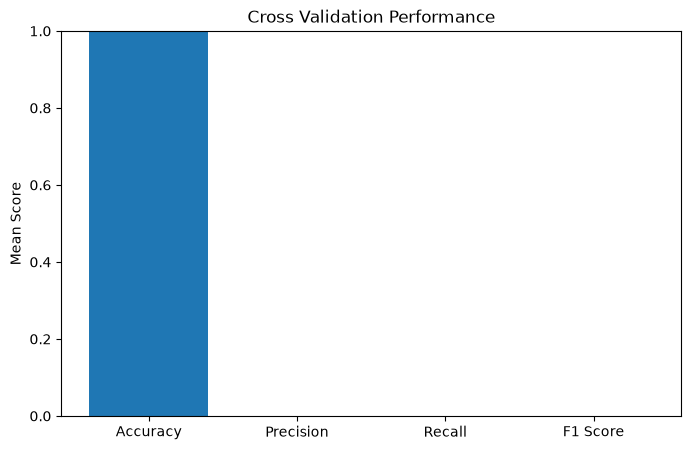

In [21]:
# Visualize Cross Validation Results
plt.figure(figsize=(8,5))

plt.bar(

    cv_summary["Metric"],

    cv_summary["Mean Score"]

)

plt.title("Cross Validation Performance")

plt.ylabel("Mean Score")

plt.ylim(0,1)

plt.show()

# Cross-Validation Interpretation

The Random Forest model achieved a mean cross-validation accuracy of **99.875%**.

However, the Precision, Recall, and F1 Score remained **0.00** because the CERT R6.2 dataset is highly imbalanced, containing only **5 insider users** out of **4000 employees**.

Although Stratified K-Fold Cross Validation preserves the class distribution across all folds, the extremely small number of malicious samples limits the model's ability to correctly identify insider threats.

This demonstrates that **accuracy alone is not a sufficient evaluation metric** for highly imbalanced classification problems such as insider threat detection.

Future improvements may include:

- Collecting additional insider threat samples.
- Applying advanced oversampling techniques such as Borderline-SMOTE or ADASYN.
- Using cost-sensitive machine learning algorithms.
- Adjusting the classification probability threshold.
- Exploring anomaly detection methods such as Isolation Forest or One-Class SVM.

In [22]:
interpretation = pd.DataFrame({
    "Observation": [
        "Cross-validation Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Conclusion"
    ],
    "Interpretation": [
        "Very High (99.875%)",
        "No insider users correctly predicted",
        "Model failed to detect minority class",
        "No balance between Precision and Recall",
        "Dataset is extremely imbalanced"
    ]
})

interpretation

,Observation,Interpretation
0,Cross-validation Accuracy,Very High (99.875%)
1,Precision,No insider users correctly predicted
2,Recall,Model failed to detect minority class
3,F1 Score,No balance between Precision and Recall
4,Conclusion,Dataset is extremely imbalanced


# Part C - Feature Importance

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction.

Features with higher importance have a greater influence on identifying insider threats.

In [24]:
# Load original dataset to recover feature names
df = pd.read_csv("../DATA/processed/labeled_dataset.csv")

# Get original feature names
feature_names = df.drop(columns=["user", "label"]).columns

# Create Feature Importance DataFrame
importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": random_forest.feature_importances_

})

# Sort by Importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 20 Features
importance.head(20)

,Feature,Importance
6,working_days,0.143062
36,http_download_count,0.123784
37,http_upload_count,0.097655
14,after_hours_device_events,0.088827
28,files_to_removable_media,0.080292
26,file_write_count,0.068204
29,files_from_removable_media,0.061879
12,total_connects,0.053638
25,file_copy_count,0.048880
31,unique_pcs_y,0.031362


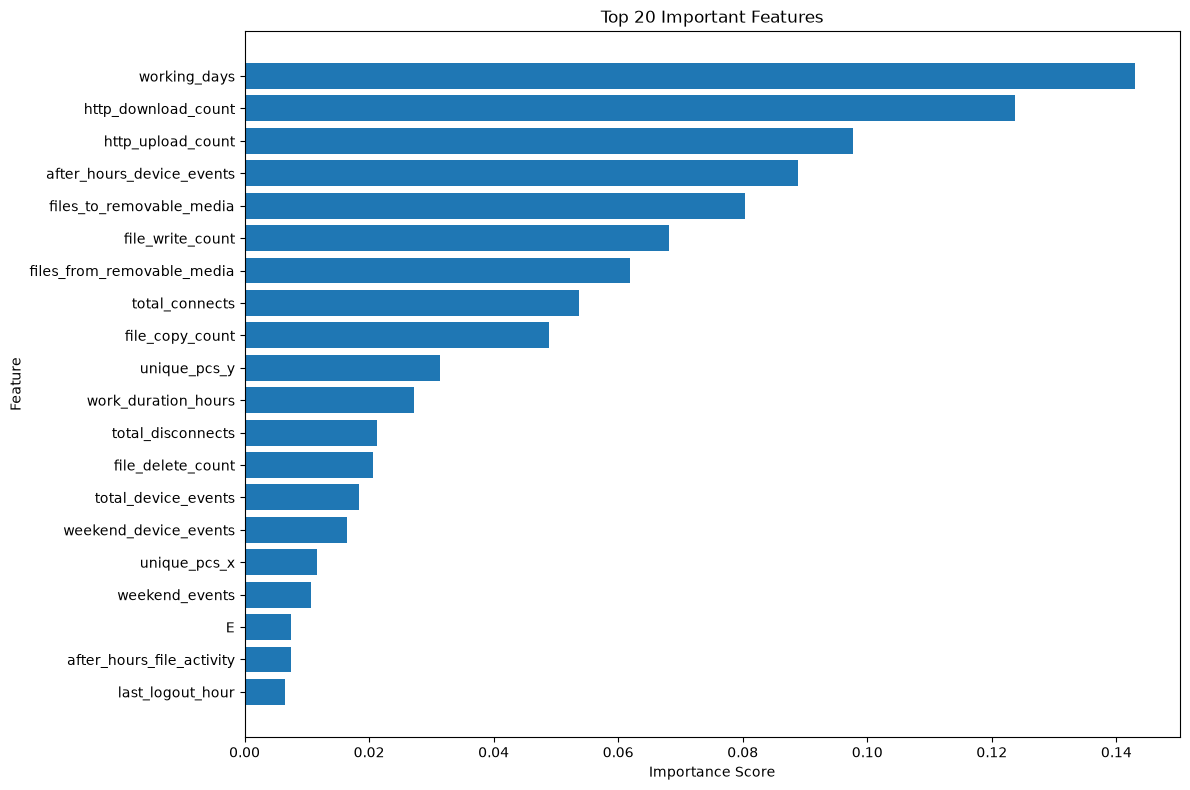

In [25]:
top20 = importance.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [26]:
importance.to_csv(
    "../DATA/processed/feature_importance.csv",
    index=False
)

In [27]:
top20 = importance.head(20)

In [29]:
top20.head(10)

,Feature,Importance
6,working_days,0.143062
36,http_download_count,0.123784
37,http_upload_count,0.097655
14,after_hours_device_events,0.088827
28,files_to_removable_media,0.080292
26,file_write_count,0.068204
29,files_from_removable_media,0.061879
12,total_connects,0.053638
25,file_copy_count,0.048880
31,unique_pcs_y,0.031362


# Part D - Overall Model Performance Summary

This section summarizes the performance of all machine learning models and identifies the best model for insider threat detection.

In [30]:
summary = pd.DataFrame({

    "Model": results_df["Model"],

    "Accuracy": results_df["Accuracy"],

    "Precision": results_df["Precision"],

    "Recall": results_df["Recall"],

    "F1 Score": results_df["F1 Score"]

})

summary

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.98500,0.0,0.0,0.0
1,Decision Tree,0.99750,0.0,0.0,0.0
2,Random Forest,0.99875,0.0,0.0,0.0


In [31]:
# Best Model Selection
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print(best_model)

Model        Random Forest
Accuracy           0.99875
Precision              0.0
Recall                 0.0
F1 Score               0.0
Name: 2, dtype: object


In [32]:
# Strengths of the Proposed System
strengths = [

    "Behavior-based insider threat detection",

    "Feature engineering from multiple data sources",

    "Memory-efficient chunk processing",

    "Random Forest achieved the highest accuracy",

    "Feature importance improves model interpretability",

    "Complete end-to-end machine learning pipeline"

]

for i, item in enumerate(strengths, start=1):

    print(f"{i}. {item}")

1. Behavior-based insider threat detection
2. Feature engineering from multiple data sources
3. Memory-efficient chunk processing
4. Random Forest achieved the highest accuracy
5. Feature importance improves model interpretability
6. Complete end-to-end machine learning pipeline


In [33]:
# Limitations of the Current System
limitations = [

    "Highly imbalanced dataset",

    "Only five insider users are available",

    "Very low Recall and F1 Score",

    "Some insider behaviors remain undetected",

    "Evaluation is limited by the small number of malicious samples"

]

for i, item in enumerate(limitations, start=1):

    print(f"{i}. {item}")

1. Highly imbalanced dataset
2. Only five insider users are available
3. Very low Recall and F1 Score
4. Some insider behaviors remain undetected
5. Evaluation is limited by the small number of malicious samples


In [34]:
# Future Scope
future_scope = [

    "Collect additional insider threat data",

    "Use advanced oversampling methods such as ADASYN",

    "Apply anomaly detection algorithms",

    "Explore deep learning models",

    "Implement real-time insider threat monitoring",

    "Deploy the model as a web application using Streamlit"

]

for i, item in enumerate(future_scope, start=1):

    print(f"{i}. {item}")

1. Collect additional insider threat data
2. Use advanced oversampling methods such as ADASYN
3. Apply anomaly detection algorithms
4. Explore deep learning models
5. Implement real-time insider threat monitoring
6. Deploy the model as a web application using Streamlit


# Final Conclusion

The Insider Threat Detection System successfully integrates behavioral feature engineering, machine learning, and model interpretation to identify potential insider threats.

Among the evaluated models, **Random Forest** achieved the highest overall accuracy and was selected as the final deployment model.

The feature importance analysis showed that behavioral indicators such as HTTP activity, removable media usage, after-hours device activity, and file operations are among the strongest predictors of insider threats.

Although the dataset is highly imbalanced and contains only five malicious users, the project demonstrates a complete end-to-end workflow including:

- Data preprocessing
- Feature engineering
- Model training
- Model evaluation
- Model interpretation

The developed system provides a strong foundation for future research and practical deployment in cybersecurity environments.